In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,StratifiedKFold,cross_val_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import ( StandardScaler, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.base import clone

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier)
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

In [56]:
df=pd.read_csv('/content/bank_personal_loan_cleaned.csv',dtype={'ZIP Code':str})

In [57]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   object 
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11), object(1)
memory usage: 507.9+ KB


In [59]:
df['ZIP Code'].value_counts().shape

(467,)

In [60]:
X = df.drop(columns=["Personal Loan"])
y = df["Personal Loan"]

In [61]:
target_distribution = pd.DataFrame({
    "Count": (y.value_counts().sort_index()),
    "Percentage": (y.value_counts(normalize=True).sort_index().mul(100).round(2))})

target_distribution

,Count,Percentage
Personal Loan,,
0,4520,90.4
1,480,9.6


In [62]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=0, stratify=y)

In [63]:
numerical_columns = ["Age","Experience","Income","CCAvg","Mortgage"]
categorical_columns = ["ZIP Code","Family","Education","Securities Account","CD Account","Online","CreditCard"]

In [64]:
#Create the preprocessing system
preprocessor = ColumnTransformer(
    transformers=[("numerical_processing",StandardScaler(),numerical_columns  ),
                  ("categorical_processing",OneHotEncoder( handle_unknown="ignore"),categorical_columns)
                  ],remainder="drop")

In [65]:
# base model
logistic_pipeline = Pipeline([("preprocessor",preprocessor), ( "model", LogisticRegression(class_weight="balanced",max_iter=3000,random_state=0) )])

In [66]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=0)

In [67]:
scores = cross_val_score(logistic_pipeline,X_train,y_train,cv=cv,scoring="f1",n_jobs=-1)

In [68]:
print("Fold F1 scores:", scores)
print("Mean CV F1:", scores.mean())
print("F1 standard deviation:", scores.std())

Fold F1 scores: [0.64615385 0.68085106 0.65714286 0.71794872 0.63157895]
Mean CV F1: 0.6667350864887259
F1 standard deviation: 0.030244501315132642


### Baseline Logistic Regression Result

The Logistic Regression model achieved a mean five-fold cross-validation F1
score of approximately 0.667, with a standard deviation of approximately 0.030.

The relatively small standard deviation indicates that the model performance is
reasonably stable across the validation folds. However, this is only a baseline
result and must be compared with other classification algorithms before
selecting the final model.

**Feature Importance Implementation**

In [72]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

class_ratio = negative_count / positive_count

print("Class 0 count:", negative_count)
print("Class 1 count:", positive_count)
print("Class ratio:", class_ratio)

Class 0 count: 3616
Class 1 count: 384
Class ratio: 9.416666666666666


**Define all baseline algorithms**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=3000, random_state=0),

    "KNN": KNeighborsClassifier(n_neighbors=5,n_jobs=1),

    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=0),

    "Random Forest": RandomForestClassifier( n_estimators=200, class_weight="balanced", random_state=0, n_jobs=1),

    "AdaBoost": AdaBoostClassifier(n_estimators=100,random_state=0),

    "Gradient Boosting": GradientBoostingClassifier( n_estimators=100, random_state=0),

    "XGBoost": XGBClassifier( n_estimators=100, max_depth=3, learning_rate=0.1, objective="binary:logistic", eval_metric="logloss", scale_pos_weight=class_ratio,random_state=0, n_jobs=1 )
}

Create stratified cross-validation

In [74]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=0)

In [75]:
f1_scorer = make_scorer(f1_score,zero_division=0)

Train every model and calculate feature importance

In [76]:
# Original feature names before one-hot encoding
feature_names = X_train.columns.tolist()

# Store feature importance for every algorithm
model_importance_dictionary = {}

# Store F1 performance of every algorithm
model_performance_results = []

In [77]:
for model_name, estimator in models.items():
    print("\n" + "=" * 60)
    print("Running model:", model_name)
    print("=" * 60)

    # Store five-fold results for the current model
    fold_f1_scores = []
    fold_importances = []

    for fold_number, (training_index,validation_index) in enumerate(cv.split(X_train, y_train),start=1):

        # -----------------------------------------
        # Current fold training data
        # -----------------------------------------

        X_fold_train = X_train.iloc[training_index]
        y_fold_train = y_train.iloc[training_index]

        # -----------------------------------------
        # Current fold validation data
        # -----------------------------------------

        X_fold_validation = X_train.iloc[validation_index]
        y_fold_validation = y_train.iloc[validation_index]

        # -----------------------------------------
        # Create a fresh pipeline for this fold
        # -----------------------------------------

        fold_pipeline = Pipeline([("preprocessor",clone(preprocessor)),("model",clone(estimator))])

        # -----------------------------------------
        # Train the model
        # -----------------------------------------

        fold_pipeline.fit( X_fold_train, y_fold_train)

        # -----------------------------------------
        # Predict validation data
        # -----------------------------------------

        y_fold_prediction = fold_pipeline.predict( X_fold_validation)

        # -----------------------------------------
        # Calculate validation F1
        # -----------------------------------------

        fold_f1 = f1_score(y_fold_validation,y_fold_prediction,zero_division=0)
        fold_f1_scores.append(fold_f1 )

        # -----------------------------------------
        # Permutation feature importance
        # -----------------------------------------

        permutation_result = permutation_importance(
            estimator=fold_pipeline,
            X=X_fold_validation,
            y=y_fold_validation,
            scoring=f1_scorer,
            n_repeats=5,
            random_state=fold_number,
            n_jobs=-1
        )

        # Save importance of all original features
        fold_importances.append(permutation_result.importances_mean)

        print(f"Fold {fold_number} F1: "
            f"{fold_f1:.4f}")

    # ---------------------------------------------
    # Average importance across all five folds
    # ---------------------------------------------

    mean_model_importance = np.mean(fold_importances,axis=0)

    model_importance_dictionary[model_name] = mean_model_importance

    # ---------------------------------------------
    # Save model performance
    # ---------------------------------------------

    model_performance_results.append({"Model": model_name,"Mean CV F1": np.mean(fold_f1_scores),"F1 Standard Deviation": np.std(fold_f1_scores)})

    print(
        f"\n{model_name} Mean F1: "
        f"{np.mean(fold_f1_scores):.4f}")


Running model: Logistic Regression
Fold 1 F1: 0.6462
Fold 2 F1: 0.6809
Fold 3 F1: 0.6571
Fold 4 F1: 0.7179
Fold 5 F1: 0.6316

Logistic Regression Mean F1: 0.6667

Running model: KNN
Fold 1 F1: 0.7333
Fold 2 F1: 0.6250
Fold 3 F1: 0.7597
Fold 4 F1: 0.6000
Fold 5 F1: 0.7520

KNN Mean F1: 0.6940

Running model: Decision Tree
Fold 1 F1: 0.8846
Fold 2 F1: 0.8917
Fold 3 F1: 0.9079
Fold 4 F1: 0.8571
Fold 5 F1: 0.8553

Decision Tree Mean F1: 0.8793

Running model: Random Forest
Fold 1 F1: 0.8358
Fold 2 F1: 0.8696
Fold 3 F1: 0.8696
Fold 4 F1: 0.8507
Fold 5 F1: 0.8777

Random Forest Mean F1: 0.8607

Running model: AdaBoost
Fold 1 F1: 0.8252
Fold 2 F1: 0.8276
Fold 3 F1: 0.8169
Fold 4 F1: 0.7910
Fold 5 F1: 0.7815

AdaBoost Mean F1: 0.8084

Running model: Gradient Boosting
Fold 1 F1: 0.9103
Fold 2 F1: 0.9014
Fold 3 F1: 0.9536
Fold 4 F1: 0.9028
Fold 5 F1: 0.9200

Gradient Boosting Mean F1: 0.9176

Running model: XGBoost
Fold 1 F1: 0.8727
Fold 2 F1: 0.9202
Fold 3 F1: 0.9091
Fold 4 F1: 0.8757
Fold 5 F

In [78]:
model_performance_df = pd.DataFrame(model_performance_results)
model_performance_df = (model_performance_df.sort_values(by="Mean CV F1",ascending=False).reset_index(drop=True))
model_performance_df[["Mean CV F1","F1 Standard Deviation"]] = model_performance_df[[ "Mean CV F1", "F1 Standard Deviation"]].round(4)

model_performance_df

,Model,Mean CV F1,F1 Standard Deviation
0,Gradient Boosting,0.9176,0.0192
1,XGBoost,0.8887,0.0218
2,Decision Tree,0.8793,0.0203
3,Random Forest,0.8607,0.0153
4,AdaBoost,0.8084,0.0187
5,KNN,0.6940,0.0676
6,Logistic Regression,0.6667,0.0302


Plot model performance

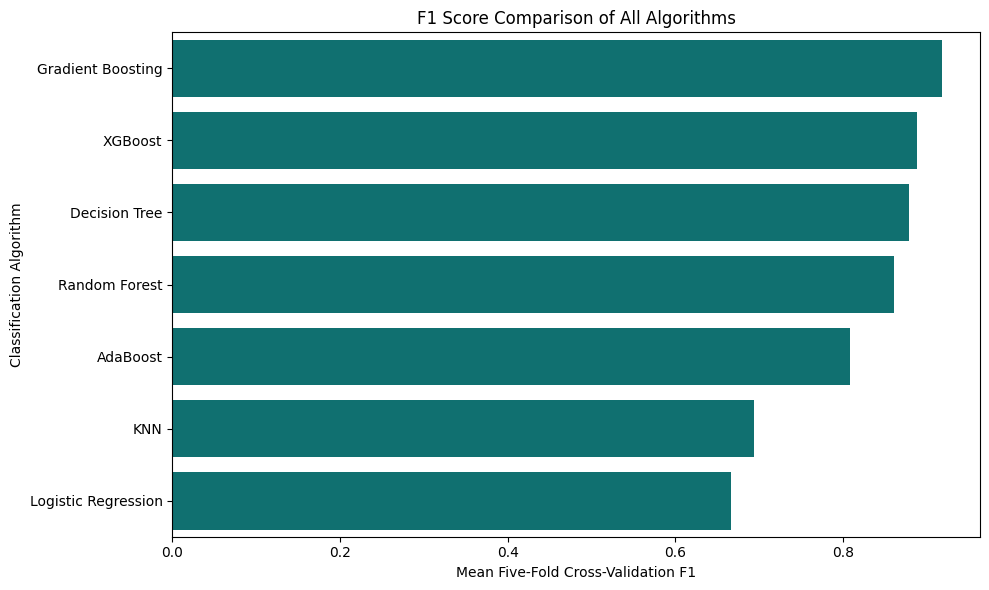

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(data=model_performance_df,x="Mean CV F1",y="Model",color='teal')
plt.title("F1 Score Comparison of All Algorithms")
plt.xlabel("Mean Five-Fold Cross-Validation F1")
plt.ylabel("Classification Algorithm")
plt.tight_layout()
plt.show()

Create feature-importance matrix

In [81]:
importance_matrix = pd.DataFrame(model_importance_dictionary,index=feature_names)
importance_matrix.index.name = "Feature"
importance_matrix.round(4)

,Logistic Regression,KNN,Decision Tree,Random Forest,AdaBoost,Gradient Boosting,XGBoost
Feature,,,,,,,
Age,0.0004,0.0003,0.0027,0.0083,0.0004,0.0003,0.0056
Experience,0.0150,0.0011,0.0026,0.0071,0.0005,0.0027,0.0039
Income,0.4097,0.4455,0.6472,0.5881,0.5810,0.6901,0.6258
ZIP Code,-0.0006,0.0021,0.0002,0.0005,-0.0015,-0.0012,0.0007
Family,0.0505,0.0664,0.2363,0.1149,0.0745,0.2415,0.2237
CCAvg,0.0007,0.1156,0.0757,0.1197,0.1068,0.0532,0.0808
Education,0.1151,0.2164,0.3088,0.3005,0.2350,0.3218,0.2928
Mortgage,0.0031,-0.0007,-0.0070,0.0069,-0.0045,0.0000,-0.0001
Securities Account,0.0054,0.0147,0.0000,0.0075,0.0000,0.0000,0.0019


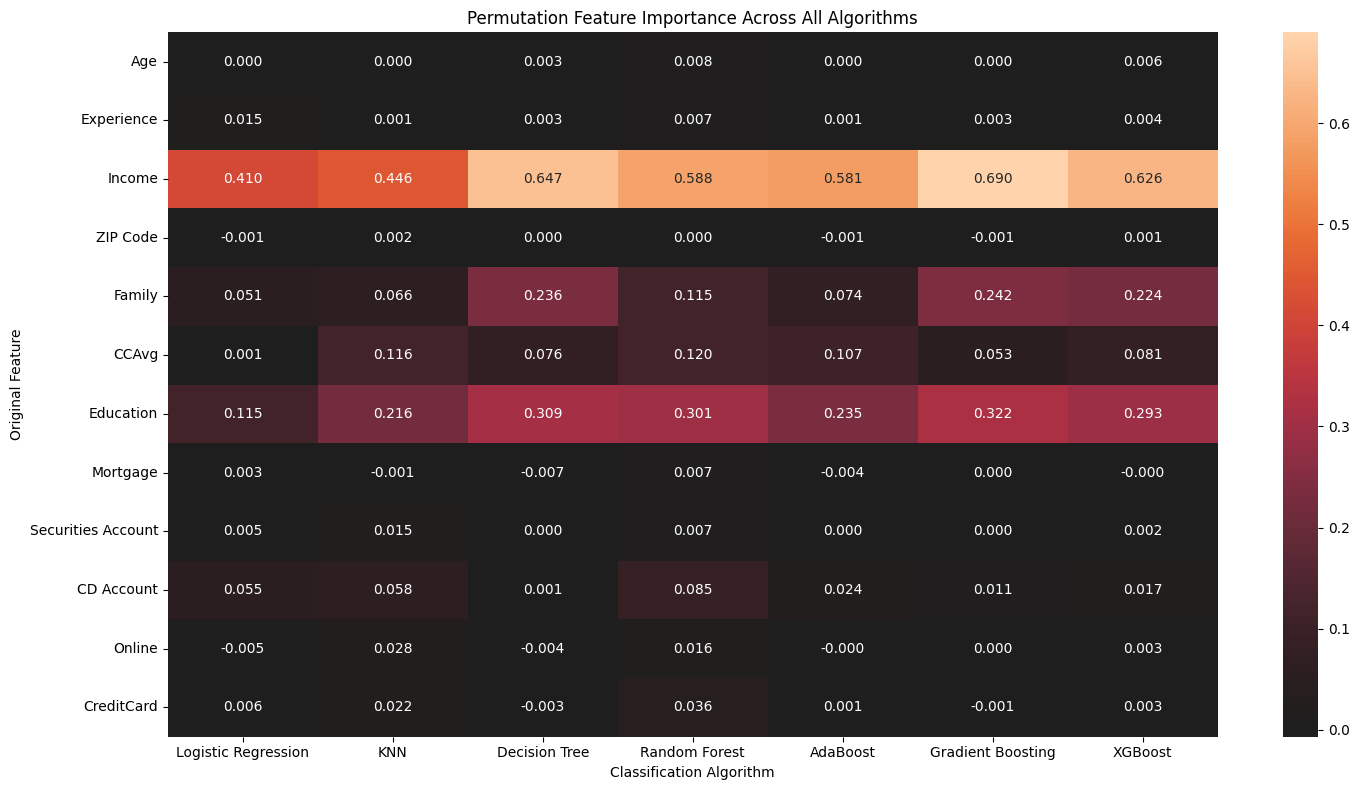

In [82]:
#Heatmap of importance
plt.figure(figsize=(15, 8))
sns.heatmap( importance_matrix, annot=True, fmt=".3f", center=0)
plt.title("Permutation Feature Importance Across All Algorithms")

plt.xlabel("Classification Algorithm")
plt.ylabel("Original Feature")

plt.tight_layout()
plt.show()

In [85]:
#Remove negative values only for merging
positive_importance = importance_matrix.clip(lower=0)
positive_importance.round(4)

,Logistic Regression,KNN,Decision Tree,Random Forest,AdaBoost,Gradient Boosting,XGBoost
Feature,,,,,,,
Age,0.0004,0.0003,0.0027,0.0083,0.0004,0.0003,0.0056
Experience,0.0150,0.0011,0.0026,0.0071,0.0005,0.0027,0.0039
Income,0.4097,0.4455,0.6472,0.5881,0.5810,0.6901,0.6258
ZIP Code,0.0000,0.0021,0.0002,0.0005,0.0000,0.0000,0.0007
Family,0.0505,0.0664,0.2363,0.1149,0.0745,0.2415,0.2237
CCAvg,0.0007,0.1156,0.0757,0.1197,0.1068,0.0532,0.0808
Education,0.1151,0.2164,0.3088,0.3005,0.2350,0.3218,0.2928
Mortgage,0.0031,0.0000,0.0000,0.0069,0.0000,0.0000,0.0000
Securities Account,0.0054,0.0147,0.0000,0.0075,0.0000,0.0000,0.0019


In [89]:
#Normalize importance inside every model
importance_totals = (positive_importance.sum(axis=0).replace(0, np.nan))
normalized_importance = (positive_importance.div(importance_totals,axis=1).fillna(0))

normalized_importance.round(4)

,Logistic Regression,KNN,Decision Tree,Random Forest,AdaBoost,Gradient Boosting,XGBoost
Feature,,,,,,,
Age,0.0005,0.0004,0.0021,0.0064,0.0004,0.0003,0.0044
Experience,0.0227,0.0012,0.0020,0.0055,0.0005,0.0020,0.0031
Income,0.6197,0.4594,0.5079,0.4558,0.5680,0.5225,0.4976
ZIP Code,0.0000,0.0021,0.0002,0.0004,0.0000,0.0000,0.0006
Family,0.0764,0.0685,0.1854,0.0891,0.0728,0.1829,0.1779
CCAvg,0.0011,0.1192,0.0594,0.0928,0.1044,0.0403,0.0642
Education,0.1740,0.2232,0.2423,0.2330,0.2297,0.2437,0.2328
Mortgage,0.0046,0.0000,0.0000,0.0054,0.0000,0.0000,0.0000
Securities Account,0.0081,0.0152,0.0000,0.0058,0.0000,0.0000,0.0015


In [90]:
#Calculate model weights
model_weights = ( model_performance_df.set_index("Model")["Mean CV F1"].reindex(normalized_importance.columns))
model_weights = model_weights.clip( lower=0)
model_weights = (model_weights /model_weights.sum())

model_weights.round(4)

,Mean CV F1
Logistic Regression,0.1166
KNN,0.1214
Decision Tree,0.1538
Random Forest,0.1506
AdaBoost,0.1414
Gradient Boosting,0.1605
XGBoost,0.1555


In [93]:
#Merge importance from all models
combined_importance = (normalized_importance.mul(model_weights,axis=1).sum(axis=1))

In [96]:
rank_matrix = importance_matrix.rank(ascending=False,method="average")
average_rank = rank_matrix.mean(axis=1)
positive_model_count = (importance_matrix > 0).sum(axis=1)

In [98]:
final_feature_importance = pd.DataFrame({"Feature": importance_matrix.index, "Combined Importance": (combined_importance.values),
    "Average Rank": (average_rank.values),
    "Positive Model Count": ( positive_model_count.values),

    "Mean Raw Importance": (importance_matrix.mean(axis=1).values)})

In [99]:
final_feature_importance = ( final_feature_importance .sort_values( by=[ "Combined Importance", "Positive Model Count" ],
        ascending=[False,False]).reset_index(drop=True))

In [100]:
final_feature_importance[[ "Combined Importance", "Average Rank", "Mean Raw Importance"]] = final_feature_importance[ ["Combined Importance","Average Rank","Mean Raw Importance" ]].round(4)

final_feature_importance

,Feature,Combined Importance,Average Rank,Positive Model Count,Mean Raw Importance
0,Income,0.5165,1.0000,7,0.5696
1,Education,0.2276,2.0000,7,0.2558
2,Family,0.1265,3.5714,7,0.1440
3,CCAvg,0.0689,4.2857,7,0.0789
4,CD Account,0.0338,5.0000,7,0.0358
5,CreditCard,0.0084,7.8571,5,0.0091
6,Online,0.0057,8.8571,4,0.0053
7,Experience,0.0048,7.2857,7,0.0047
8,Securities Account,0.0039,8.7857,4,0.0042
9,Age,0.0022,7.8571,7,0.0026


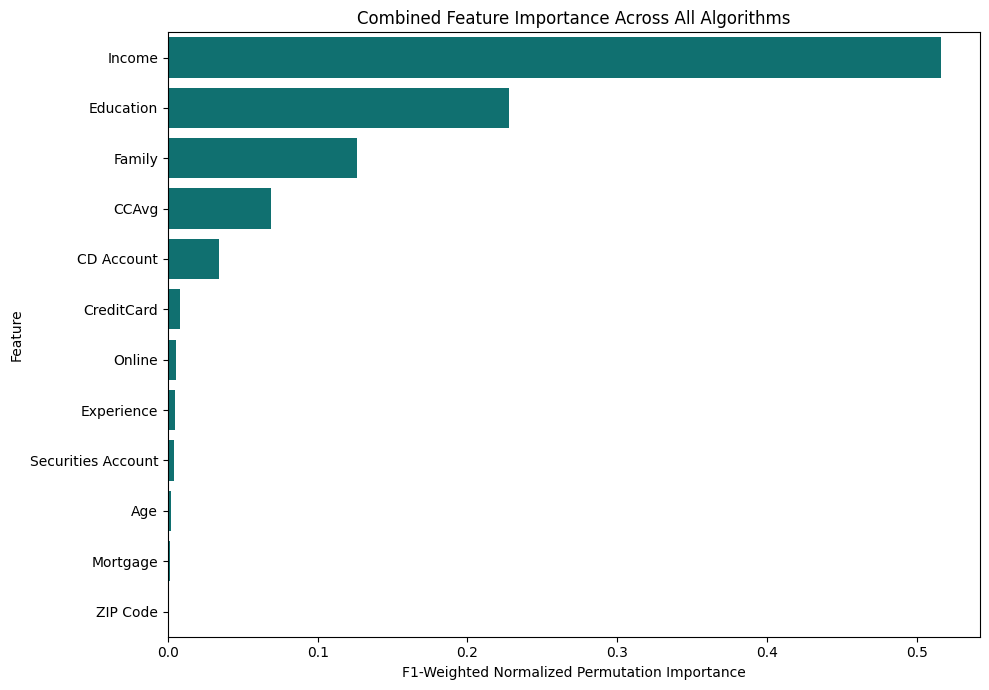

In [102]:
plt.figure(figsize=(10, 7))
sns.barplot(data=final_feature_importance,x="Combined Importance",y="Feature",color='teal')
plt.title("Combined Feature Importance Across All Algorithms")
plt.xlabel("F1-Weighted Normalized Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [104]:
final_feature_importance[ "Cumulative Importance"] = (final_feature_importance["Combined Importance"].cumsum())

final_feature_importance

,Feature,Combined Importance,Average Rank,Positive Model Count,Mean Raw Importance,Cumulative Importance
0,Income,0.5165,1.0000,7,0.5696,0.5165
1,Education,0.2276,2.0000,7,0.2558,0.7441
2,Family,0.1265,3.5714,7,0.1440,0.8706
3,CCAvg,0.0689,4.2857,7,0.0789,0.9395
4,CD Account,0.0338,5.0000,7,0.0358,0.9733
5,CreditCard,0.0084,7.8571,5,0.0091,0.9817
6,Online,0.0057,8.8571,4,0.0053,0.9874
7,Experience,0.0048,7.2857,7,0.0047,0.9922
8,Securities Account,0.0039,8.7857,4,0.0042,0.9961
9,Age,0.0022,7.8571,7,0.0026,0.9983


In [105]:
all_features = X_train.columns.tolist()
top_4_features = ( final_feature_importance.head(4)["Feature"].tolist())
top_5_features = (final_feature_importance.head(5)["Feature"].tolist())

In [106]:
#Create a function that selects features covering 99% importance:
def select_features_by_importance(importance_table,threshold):
    cumulative = (importance_table["Combined Importance"].cumsum())

    number_of_features = (cumulative < threshold).sum() + 1

    return (importance_table.head(number_of_features)["Feature"].tolist())

In [107]:
top_99_features = select_features_by_importance(final_feature_importance,threshold=0.99)

In [109]:
print("All features:",all_features)
print("\nTop 4 features:",top_4_features)
print("\nTop 5 features:",top_5_features)
print("\nTop 99% features:",top_99_features)


All features: ['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

Top 4 features: ['Income', 'Education', 'Family', 'CCAvg']

Top 5 features: ['Income', 'Education', 'Family', 'CCAvg', 'CD Account']

Top 99% features: ['Income', 'Education', 'Family', 'CCAvg', 'CD Account', 'CreditCard', 'Online', 'Experience']


In [110]:
#Store the feature sets
feature_sets = {"All Features": all_features,"Top 4 Features": top_4_features,"Top 5 Features": top_5_features,"99 Percent Importance": top_99_features}

In [111]:
#Select the best four baseline models
top_model_names = (model_performance_df.head(4)["Model"].tolist())

top_models = {model_name: models[model_name]for model_name in top_model_names}
print(top_model_names)

['Gradient Boosting', 'XGBoost', 'Decision Tree', 'Random Forest']


In [114]:
# Compare every feature set
feature_selection_results = []

for feature_set_name, selected_features in feature_sets.items():
    print("\n" + "=" * 60)
    print("Feature set:", feature_set_name)
    print("Features:", selected_features)
    print("=" * 60)

    # Numerical columns available in this feature set
    current_numerical_columns = [ column for column in numerical_columns if column in selected_features]

    # Categorical columns available in this feature set
    current_categorical_columns = [column for column in categorical_columns if column in selected_features]
    transformers = []

    if current_numerical_columns:
        transformers.append(("numerical",StandardScaler(),current_numerical_columns))

    if current_categorical_columns:
        transformers.append(( "categorical", OneHotEncoder(handle_unknown="ignore"),current_categorical_columns))

    current_preprocessor = ColumnTransformer(transformers=transformers,remainder="drop")

    X_current = X_train[selected_features]

    for model_name, estimator in top_models.items():

        current_pipeline = Pipeline([ ("preprocessor",current_preprocessor),("model",clone(estimator))])

        scores = cross_val_score(
            current_pipeline,
            X_current,
            y_train,
            cv=cv,
            scoring=f1_scorer,
            n_jobs=-1
        )

        feature_selection_results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Number of Features": len(selected_features),
            "Mean CV F1": scores.mean(),
            "F1 Standard Deviation": scores.std()
        })

        print(model_name,"Mean F1:",round(scores.mean(), 4))


Feature set: All Features
Features: ['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
Gradient Boosting Mean F1: 0.9176
XGBoost Mean F1: 0.8887
Decision Tree Mean F1: 0.8793
Random Forest Mean F1: 0.8607

Feature set: Top 4 Features
Features: ['Income', 'Education', 'Family', 'CCAvg']
Gradient Boosting Mean F1: 0.9274
XGBoost Mean F1: 0.8686
Decision Tree Mean F1: 0.9011
Random Forest Mean F1: 0.9175

Feature set: Top 5 Features
Features: ['Income', 'Education', 'Family', 'CCAvg', 'CD Account']
Gradient Boosting Mean F1: 0.9208
XGBoost Mean F1: 0.8859
Decision Tree Mean F1: 0.9087
Random Forest Mean F1: 0.927

Feature set: 99 Percent Importance
Features: ['Income', 'Education', 'Family', 'CCAvg', 'CD Account', 'CreditCard', 'Online', 'Experience']
Gradient Boosting Mean F1: 0.9266
XGBoost Mean F1: 0.8843
Decision Tree Mean F1: 0.91
Random Forest Mean F1: 0.9199


In [115]:
#Create the result table
feature_selection_results_df = pd.DataFrame(feature_selection_results)
feature_selection_results_df[["Mean CV F1","F1 Standard Deviation"]] = feature_selection_results_df[["Mean CV F1","F1 Standard Deviation"]].round(4)

feature_selection_results_df.sort_values(by=["Model","Mean CV F1"],ascending=[True,False ])

,Feature Set,Model,Number of Features,Mean CV F1,F1 Standard Deviation
14,99 Percent Importance,Decision Tree,8,0.9100,0.0193
10,Top 5 Features,Decision Tree,5,0.9087,0.0217
6,Top 4 Features,Decision Tree,4,0.9011,0.0129
2,All Features,Decision Tree,12,0.8793,0.0203
4,Top 4 Features,Gradient Boosting,4,0.9274,0.0101
12,99 Percent Importance,Gradient Boosting,8,0.9266,0.0174
8,Top 5 Features,Gradient Boosting,5,0.9208,0.0206
0,All Features,Gradient Boosting,12,0.9176,0.0192
11,Top 5 Features,Random Forest,5,0.9270,0.0213
15,99 Percent Importance,Random Forest,8,0.9199,0.0100


In [116]:
comparison_table = (feature_selection_results_df.pivot(index="Model",columns="Feature Set",values="Mean CV F1"))

comparison_table.round(4)

Feature Set,99 Percent Importance,All Features,Top 4 Features,Top 5 Features
Model,,,,
Decision Tree,0.9100,0.8793,0.9011,0.9087
Gradient Boosting,0.9266,0.9176,0.9274,0.9208
Random Forest,0.9199,0.8607,0.9175,0.9270
XGBoost,0.8843,0.8887,0.8686,0.8859


In [118]:
best_feature_set_per_model = (feature_selection_results_df .loc[feature_selection_results_df.groupby("Model")["Mean CV F1"].idxmax()]
    .sort_values("Mean CV F1",ascending=False).reset_index(drop=True))

best_feature_set_per_model

,Feature Set,Model,Number of Features,Mean CV F1,F1 Standard Deviation
0,Top 4 Features,Gradient Boosting,4,0.9274,0.0101
1,Top 5 Features,Random Forest,5,0.9270,0.0213
2,99 Percent Importance,Decision Tree,8,0.9100,0.0193
3,All Features,XGBoost,12,0.8887,0.0218


### Conclusion

Gradient Boosting with the top four features achieved the best result, with a mean five-fold cross-validation F1 score of **0.9274** and a standard deviation of **0.0101**. The selected features are **Income, Education, Family, and CCAvg**.

Random Forest with the top five features achieved a nearly identical F1 score of **0.9270**, but it showed greater variation across folds. Therefore, Gradient Boosting is selected as the primary candidate and Random Forest as the secondary candidate for hyperparameter tuning. The final decision will be made after tuning, without using the untouched test set.

# **hyperparameter tuning**

In [119]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.7 MB/s eta 0:00:00


In [120]:
import optuna

In [121]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [122]:
#Define the two feature sets
gradient_boosting_features = (final_feature_importance.head(4)["Feature"].tolist())

random_forest_features = ( final_feature_importance.head(5)["Feature"].tolist())

In [125]:
print("Gradient Boosting features:",gradient_boosting_features
      ,"\nRandom Forest features:",random_forest_features)



Gradient Boosting features: ['Income', 'Education', 'Family', 'CCAvg'] 
Random Forest features: ['Income', 'Education', 'Family', 'CCAvg', 'CD Account']


In [127]:
#Create preprocessing function
def create_preprocessor(selected_features):

    current_numerical_columns = [column for column in numerical_columns if column in selected_features]

    current_categorical_columns = [column for column in categorical_columns if column in selected_features]

    transformers = []

    if current_numerical_columns:

        transformers.append(("numerical",StandardScaler(),current_numerical_columns))

    if current_categorical_columns:

        transformers.append(("categorical",OneHotEncoder( handle_unknown="ignore"),current_categorical_columns) )

    return ColumnTransformer(transformers=transformers,remainder="drop")

In [128]:
#Function to calculate cross-validation F1
def calculate_mean_cv_f1(model,selected_features):

    current_preprocessor = create_preprocessor(selected_features)

    current_pipeline = Pipeline([("preprocessor",current_preprocessor),("model",model)])

    scores = cross_val_score(
        current_pipeline,
        X_train[selected_features],
        y_train,
        cv=cv,
        scoring=f1_scorer,
        n_jobs=-1,
        error_score="raise"
    )

    return scores.mean()

In [129]:
#Gradient Boosting objective
def objective_gradient_boosting(trial):

    model = GradientBoostingClassifier(

        n_estimators=trial.suggest_int( "n_estimators", 50, 400, step=25 ),

        learning_rate=trial.suggest_float("learning_rate",0.01,0.30,log=True),

        max_depth=trial.suggest_int("max_depth",1,5),

        min_samples_split=trial.suggest_int( "min_samples_split", 2, 20),

        min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10),

        subsample=trial.suggest_float( "subsample", 0.60, 1.00, step=0.10 ),

        max_features=trial.suggest_categorical("max_features",[None,"sqrt","log2"] ),

        random_state=0
    )

    return calculate_mean_cv_f1(model,gradient_boosting_features )

In [130]:
#Run Gradient Boosting study
gradient_boosting_study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=0))

gradient_boosting_study.optimize(objective_gradient_boosting,n_trials=30)

In [131]:
print( "Gradient Boosting best CV F1:", round(gradient_boosting_study.best_value,4))
print("Best parameters:\n",gradient_boosting_study.best_params)



Gradient Boosting best CV F1: 0.9393
Best parameters:
 {'n_estimators': 250, 'learning_rate': 0.2270048873838548, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 6, 'subsample': 0.9, 'max_features': 'log2'}


In [132]:
#Random Forest objective
def objective_random_forest(trial):

    model = RandomForestClassifier(

        n_estimators=trial.suggest_int("n_estimators",200,800,step=50),

        max_depth=trial.suggest_categorical("max_depth",[None,5,8,10,12,15,20]),

        min_samples_split=trial.suggest_int( "min_samples_split", 2, 20),

        min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10),

        max_features=trial.suggest_categorical("max_features",["sqrt","log2",None] ),

        bootstrap=trial.suggest_categorical("bootstrap",[True,False]),

        class_weight=trial.suggest_categorical("class_weight",[ None, "balanced", "balanced_subsample"] ),

        random_state=0,

        # Avoid nested parallel processing
        n_jobs=1
    )

    return calculate_mean_cv_f1(model,random_forest_features)

In [133]:
#Run Random Forest study
random_forest_study = optuna.create_study( direction="maximize",sampler=optuna.samplers.TPESampler(seed=0))

random_forest_study.optimize(objective_random_forest,n_trials=30)

In [134]:
print("Random Forest best CV F1:",round(random_forest_study.best_value,4))
print("Best parameters\n:",random_forest_study.best_params)


Random Forest best CV F1: 0.9297
Best parameters
: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': None}


In [138]:
tuning_results = pd.DataFrame({"Model": ["Gradient Boosting","Random Forest"],"Feature Set": ["Top 4 Features","Top 5 Features"],
    "Features": [ gradient_boosting_features, random_forest_features],
    "Number of Features": [len(gradient_boosting_features),len(random_forest_features)],
    "Baseline CV F1": [0.9274,0.9270],
    "Tuned CV F1": [ gradient_boosting_study.best_value, random_forest_study.best_value],
    "Best Parameters": [gradient_boosting_study.best_params,random_forest_study.best_params]})

In [139]:
tuning_results["F1 Improvement"] = (tuning_results["Tuned CV F1"]-tuning_results["Baseline CV F1"])

In [140]:
tuning_results[[ "Baseline CV F1", "Tuned CV F1", "F1 Improvement"]] = tuning_results[ [ "Baseline CV F1", "Tuned CV F1", "F1 Improvement"]].round(4)

tuning_results = ( tuning_results .sort_values("Tuned CV F1",ascending=False).reset_index(drop=True))
tuning_results

,Model,Feature Set,Features,Number of Features,Baseline CV F1,Tuned CV F1,Best Parameters,F1 Improvement
0,Gradient Boosting,Top 4 Features,"[Income, Education, Family, CCAvg]",4,0.9274,0.9393,"{'n_estimators': 250, 'learning_rate': 0.22700...",0.0119
1,Random Forest,Top 5 Features,"[Income, Education, Family, CCAvg, CD Account]",5,0.9270,0.9297,"{'n_estimators': 250, 'max_depth': 20, 'min_sa...",0.0027


**CLASSIFICATION THRESHOLD TUNING AND FINAL MODEL EVALUATION**

In [146]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ( precision_recall_curve, roc_curve, average_precision_score, confusion_matrix)

In [147]:
# Selected features
gradient_boosting_features = ["Income","Education","Family","CCAvg"]
#Create tuned Gradient Boosting model
tuned_gradient_model = GradientBoostingClassifier(n_estimators=250,learning_rate=0.2270048873838548,max_depth=3,min_samples_split=10,min_samples_leaf=6,subsample=0.9,max_features="log2",random_state=0)
# Create final pipeline
tuned_gradient_pipeline = Pipeline([ ( "preprocessor", create_preprocessor(gradient_boosting_features)),("model",tuned_gradient_model)])
# Generate out-of-fold training probabilities
oof_probabilities = cross_val_predict(estimator=tuned_gradient_pipeline,X=X_train[gradient_boosting_features],y=y_train,cv=cv,method="predict_proba",n_jobs=-1)[:, 1]

In [149]:
#Calculate out-of-fold ROC-AUC
oof_roc_auc = roc_auc_score(y_train,oof_probabilities)
oof_pr_auc = average_precision_score(y_train,oof_probabilities)
print("Out-of-fold ROC-AUC:", round(oof_roc_auc, 4))
print("Out-of-fold PR-AUC:", round(oof_pr_auc, 4))

Out-of-fold ROC-AUC: 0.9961
Out-of-fold PR-AUC: 0.9813


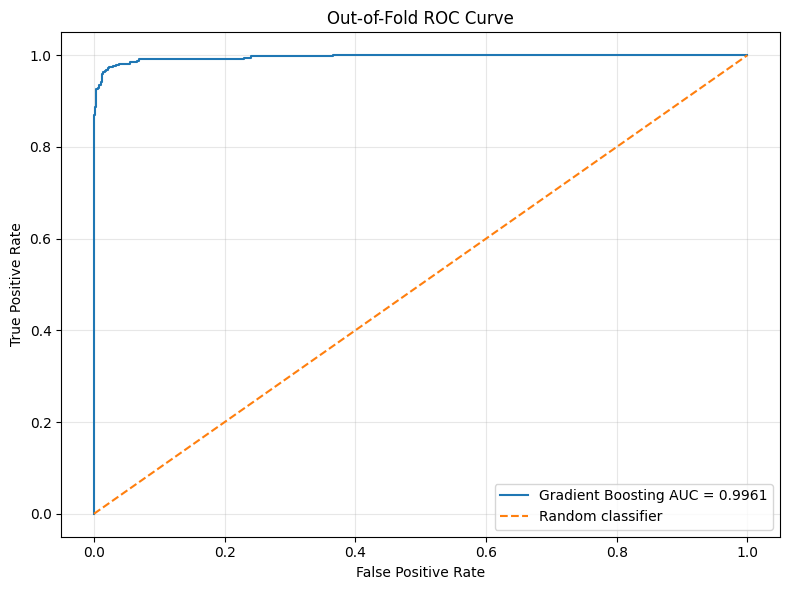

In [150]:
# Plot out-of-fold ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_train,oof_probabilities)
plt.figure(figsize=(8, 6))
plt.plot( fpr, tpr, label=f"Gradient Boosting AUC = {oof_roc_auc:.4f}")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random classifier")
plt.title("Out-of-Fold ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [152]:
# Find the threshold with maximum F1 score
precision_values, recall_values, thresholds = ( precision_recall_curve( y_train, oof_probabilities))
f1_values = ( 2 * precision_values[:-1] * recall_values[:-1] /(precision_values[:-1]+ recall_values[:-1]+ 1e-10))
best_threshold_index = np.argmax(f1_values)
best_threshold = thresholds[best_threshold_index]
best_oof_precision = precision_values[best_threshold_index]
best_oof_recall = recall_values[best_threshold_index]
best_oof_f1 = f1_values[best_threshold_index]
print("\nBest classification threshold:",round(best_threshold, 4),
      "\nOOF precision at best threshold:",round(best_oof_precision, 4),
      "\nOOF recall at best threshold:",round(best_oof_recall, 4),
      "\nOOF F1 at best threshold:",round(best_oof_f1, 4))


Best classification threshold: 0.3815 
OOF precision at best threshold: 0.9622 
OOF recall at best threshold: 0.9271 
OOF F1 at best threshold: 0.9443


In [153]:
# Compare threshold 0.50 and tuned threshold
default_oof_predictions = ( oof_probabilities >= 0.50).astype(int)
tuned_oof_predictions = (oof_probabilities >= best_threshold).astype(int)
threshold_comparison = pd.DataFrame({"Threshold Type": ["Default threshold","Tuned threshold"],"Threshold": [ 0.50, best_threshold],
        "Precision": [ precision_score(y_train,default_oof_predictions,zero_division=0),precision_score(y_train,tuned_oof_predictions,zero_division=0)],
        "Recall": [recall_score( y_train, default_oof_predictions, zero_division=0),recall_score(y_train,tuned_oof_predictions,zero_division=0)],
        "F1 Score": [f1_score(y_train,default_oof_predictions,zero_division=0),f1_score(y_train,tuned_oof_predictions,zero_division=0)]})
threshold_comparison.round(4)

,Threshold Type,Threshold,Precision,Recall,F1 Score
0,Default threshold,0.5000,0.9695,0.9115,0.9396
1,Tuned threshold,0.3815,0.9622,0.9271,0.9443


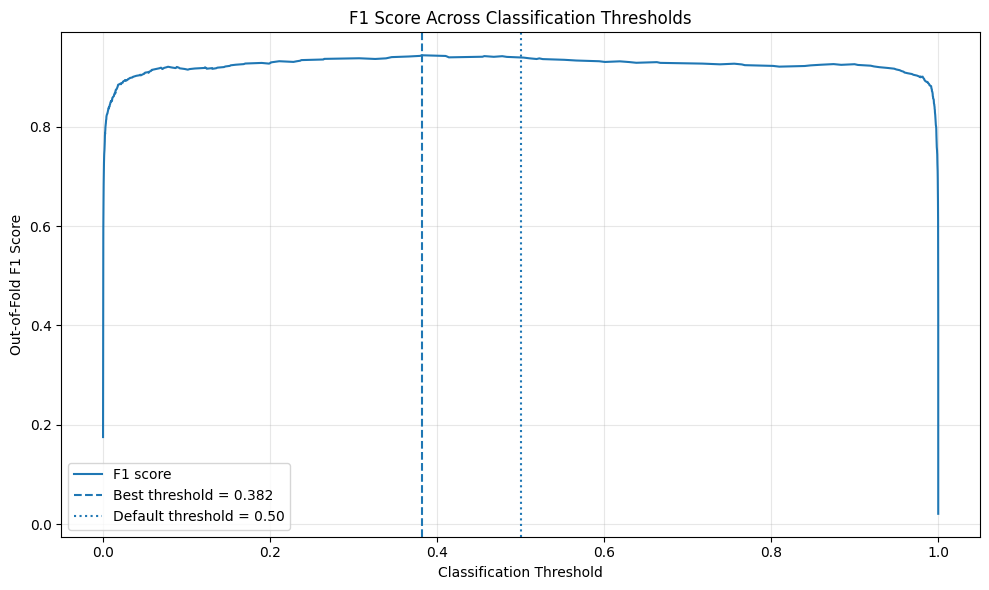

In [155]:
#F1 against threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds,f1_values,label="F1 score")
plt.axvline( best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")
plt.axvline(0.50,linestyle=":",label="Default threshold = 0.50")
plt.title("F1 Score Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Out-of-Fold F1 Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Final test-set evaluation**

In [156]:
tuned_gradient_pipeline.fit(X_train[gradient_boosting_features],y_train)
test_probabilities = tuned_gradient_pipeline.predict_proba(X_test[gradient_boosting_features])[:, 1]
test_predictions = (test_probabilities >= best_threshold).astype(int)
test_accuracy = accuracy_score(y_test,test_predictions)
test_precision = precision_score(y_test,test_predictions,zero_division=0)
test_recall = recall_score(y_test,test_predictions,zero_division=0)
test_f1 = f1_score(y_test,test_predictions,zero_division=0)
test_roc_auc = roc_auc_score(y_test,test_probabilities)
test_pr_auc = average_precision_score(y_test,test_probabilities)

final_test_results = pd.DataFrame({"Metric": ["Accuracy","Precision","Recall","F1 Score","ROC-AUC","PR-AUC"],"Test Score": [test_accuracy,test_precision,test_recall, test_f1,test_roc_auc,test_pr_auc]})
final_test_results["Test Score"] = (final_test_results["Test Score"].round(4))
final_test_results

,Metric,Test Score
0,Accuracy,0.9880
1,Precision,0.9565
2,Recall,0.9167
3,F1 Score,0.9362
4,ROC-AUC,0.9980
5,PR-AUC,0.9853


In [157]:
print("Final selected threshold:",round(best_threshold, 4))
print("\nClassification Report:\n")
print(classification_report( y_test, test_predictions, target_names=["No Personal Loan","Personal Loan"],zero_division=0 ))

Final selected threshold: 0.3815

Classification Report:

                  precision    recall  f1-score   support

No Personal Loan       0.99      1.00      0.99       904
   Personal Loan       0.96      0.92      0.94        96

        accuracy                           0.99      1000
       macro avg       0.97      0.96      0.96      1000
    weighted avg       0.99      0.99      0.99      1000



In [159]:
final_confusion_matrix = confusion_matrix( y_test, test_predictions)
final_confusion_matrix

array([[900,   4],
       [  8,  88]])

Text(0, 0.5, 'True Positive Rate')

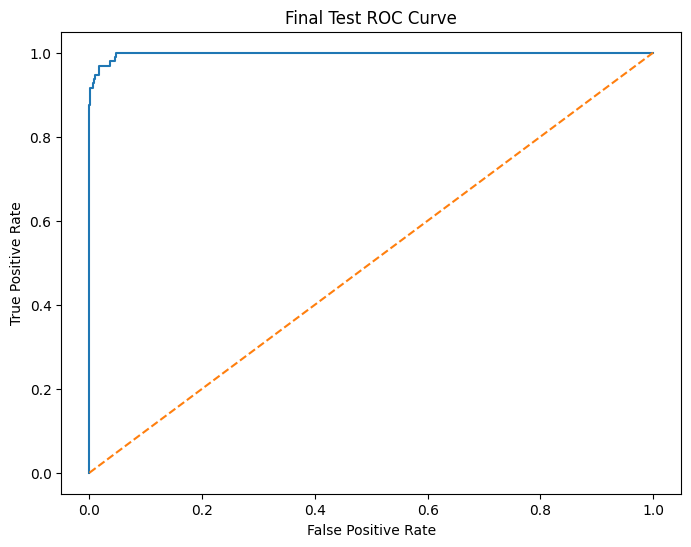

In [161]:
test_fpr, test_tpr, _ = roc_curve( y_test, test_probabilities)
plt.figure(figsize=(8, 6))
plt.plot(test_fpr,test_tpr,label=f"Test ROC-AUC = {test_roc_auc:.4f}")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random classifier")
plt.title("Final Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


In [162]:
import joblib
from sklearn.base import clone
from google.colab import files
# Create deployment model
deployment_pipeline = clone(tuned_gradient_pipeline)
# Train using complete dataset
deployment_pipeline.fit( X[gradient_boosting_features],y)
# Save model, features and threshold together
model_data = {"pipeline": deployment_pipeline,"features": gradient_boosting_features,"threshold": float(best_threshold)}
file_path = "/content/bank_loan_model.pkl"
joblib.dump(model_data, file_path)
# Download the pickle file
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>